<a href="https://colab.research.google.com/github/aldenleeSMU/EURUSD-2025-backtest/blob/main/EURUSD_2025_backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional, Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print(interval_names[:50])   # show the first 50


['INTERVAL_DAY_1', 'INTERVAL_HOUR_1', 'INTERVAL_HOUR_4', 'INTERVAL_MIN_1', 'INTERVAL_MIN_10', 'INTERVAL_MIN_15', 'INTERVAL_MIN_30', 'INTERVAL_MIN_5', 'INTERVAL_MONTH_1', 'INTERVAL_SEC_1', 'INTERVAL_SEC_10', 'INTERVAL_SEC_30', 'INTERVAL_TICK', 'INTERVAL_WEEK_1']


In [ ]:
# =============================================================================
# CONFIG
# =============================================================================

@dataclass
class BacktestConfig:
    bid_path: str = "EURUSD_5 Mins_Bid_2025.01.01_2025.12.31.csv"
    ask_path: str = "EURUSD_5 Mins_Ask_2025.01.01_2025.12.31.csv"
    timezone: str = "Asia/Singapore"

    sweep_buffer: float = 0.00005       # 0.5 pip
    stop_extension: float = 1.20        # 20% beyond impulse start
    max_hold_bars: int = 288            # 24h on 5m
    risk_pct: float = 0.005             # 0.50%
    start_equity: float = 100_000.0
    conservative_both_hit: bool = True

    pivot_k_5m: int = 2
    pivot_k_15m: int = 2
    max_mss_lookahead_5m: int = 72      # 6 hours
    max_mss_lookahead_15m: int = 24     # 6 hours

    asia_start_hour: int = 7
    asia_end_hour: int = 13
    london_start_hour: int = 13
    london_end_hour: int = 19
    ny_am_start_hour: int = 19
    ny_am_end_hour: int = 1


In [ ]:
# =============================================================================
# DATA LOADING
# =============================================================================

def load_jforex_csv(path: str) -> pd.DataFrame:
    """Load a JForex/Dukascopy-style CSV and standardize columns."""
    df = pd.read_csv(path)

    ts_candidates = [
        c for c in df.columns
        if c.lower() in {"time", "date", "gmt time", "timestamp", "datetime"}
    ]
    ts_col = ts_candidates[0] if ts_candidates else df.columns[0]

    df = df.rename(columns={ts_col: "timestamp"})
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
    df = df.dropna(subset=["timestamp"]).sort_values("timestamp").set_index("timestamp")

    rename_map = {}
    for c in df.columns:
        cl = c.lower()
        if cl in {"open", "o"}:
            rename_map[c] = "open"
        elif cl in {"high", "h"}:
            rename_map[c] = "high"
        elif cl in {"low", "l"}:
            rename_map[c] = "low"
        elif cl in {"close", "c"}:
            rename_map[c] = "close"
        elif "vol" in cl:
            rename_map[c] = "volume"

    df = df.rename(columns=rename_map)

    required = ["open", "high", "low", "close"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns {missing}. Found columns: {list(df.columns)}")

    keep = required + (["volume"] if "volume" in df.columns else [])
    return df[keep].copy()


def build_price_frame(bid: pd.DataFrame, ask: pd.DataFrame) -> pd.DataFrame:
    """Inner-join bid/ask and compute mid prices plus spread."""
    df = bid.add_prefix("bid_").join(ask.add_prefix("ask_"), how="inner").sort_index()

    df["mid_open"] = (df["bid_open"] + df["ask_open"]) / 2
    df["mid_high"] = (df["bid_high"] + df["ask_high"]) / 2
    df["mid_low"] = (df["bid_low"] + df["ask_low"]) / 2
    df["mid_close"] = (df["bid_close"] + df["ask_close"]) / 2
    df["spread_close"] = df["ask_close"] - df["bid_close"]

    return df

In [ ]:
# =============================================================================
# SESSION / RANGE
# =============================================================================

def session_label(ts: pd.Timestamp, cfg: BacktestConfig) -> str:
    hm = ts.hour + ts.minute / 60

    if cfg.asia_start_hour <= hm < cfg.asia_end_hour:
        return "ASIA"
    if cfg.london_start_hour <= hm < cfg.london_end_hour:
        return "LONDON"
    if (hm >= cfg.ny_am_start_hour) or (hm < cfg.ny_am_end_hour):
        return "NY_AM"
    return "OTHER"


def add_sessions(df: pd.DataFrame, cfg: BacktestConfig) -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.tz_convert(cfg.timezone)
    out["date_sgt"] = pd.to_datetime(out.index.date).date
    out["session"] = [session_label(ts, cfg) for ts in out.index]
    return out


def add_asian_range(df: pd.DataFrame) -> pd.DataFrame:
    asia = (
        df[df["session"] == "ASIA"]
        .groupby("date_sgt")
        .agg(
            asia_high=("mid_high", "max"),
            asia_low=("mid_low", "min"),
        )
    )

    out = df.join(asia, on="date_sgt")
    return out


def add_sweeps(df: pd.DataFrame, cfg: BacktestConfig) -> pd.DataFrame:
    out = df.copy()

    out["sweep_asia_low"] = (
        (out["session"] == "LONDON")
        & out["asia_low"].notna()
        & (out["mid_low"] < out["asia_low"] - cfg.sweep_buffer)
    )

    out["sweep_asia_high"] = (
        (out["session"] == "LONDON")
        & out["asia_high"].notna()
        & (out["mid_high"] > out["asia_high"] + cfg.sweep_buffer)
    )

    out["sweep_low_event"] = out["sweep_asia_low"] & (~out["sweep_asia_low"].shift(1).fillna(False))
    out["sweep_high_event"] = out["sweep_asia_high"] & (~out["sweep_asia_high"].shift(1).fillna(False))

    return out

In [ ]:
# =============================================================================
# HTF FVG
# =============================================================================

def resample_ohlc(df: pd.DataFrame, rule: str, prefix: str = "mid_") -> pd.DataFrame:
    o = df[f"{prefix}open"].resample(rule).first()
    h = df[f"{prefix}high"].resample(rule).max()
    l = df[f"{prefix}low"].resample(rule).min()
    c = df[f"{prefix}close"].resample(rule).last()
    return pd.DataFrame({"open": o, "high": h, "low": l, "close": c}).dropna()


def detect_fvg_zones(htf: pd.DataFrame) -> pd.DataFrame:
    """
    Bullish FVG at t: low[t] > high[t-2] => gap [high[t-2], low[t]]
    Bearish FVG at t: high[t] < low[t-2] => gap [high[t], low[t-2]]
    """
    highs = htf["high"].to_numpy()
    lows = htf["low"].to_numpy()
    idx = htf.index

    zones: List[Dict] = []

    for i in range(2, len(htf)):
        if lows[i] > highs[i - 2]:
            zones.append({
                "created_time": idx[i],
                "direction": "BULL",
                "lower": float(highs[i - 2]),
                "upper": float(lows[i]),
            })

        if highs[i] < lows[i - 2]:
            zones.append({
                "created_time": idx[i],
                "direction": "BEAR",
                "lower": float(highs[i]),
                "upper": float(lows[i - 2]),
            })

    if not zones:
        return pd.DataFrame(columns=["created_time", "direction", "lower", "upper"])

    return pd.DataFrame(zones).sort_values("created_time").reset_index(drop=True)


def build_htf_fvg(df: pd.DataFrame) -> pd.DataFrame:
    htf_30 = resample_ohlc(df, "30min")
    htf_1h = resample_ohlc(df, "1H")
    htf_4h = resample_ohlc(df, "4H")

    z30 = detect_fvg_zones(htf_30)
    if not z30.empty:
        z30["tf"] = "30m"

    z1h = detect_fvg_zones(htf_1h)
    if not z1h.empty:
        z1h["tf"] = "1H"

    z4h = detect_fvg_zones(htf_4h)
    if not z4h.empty:
        z4h["tf"] = "4H"

    zones = pd.concat([z30, z1h, z4h], ignore_index=True)
    if zones.empty:
        return pd.DataFrame(columns=["created_time", "direction", "lower", "upper", "tf", "start_time", "end_time"])

    zones = zones.sort_values("created_time").reset_index(drop=True)
    return build_active_zone_intervals(zones, df)


def build_active_zone_intervals(zones: pd.DataFrame, df: pd.DataFrame) -> pd.DataFrame:
    ends = []
    last_time = df.index.max()

    for _, zone in zones.iterrows():
        start = zone["created_time"]
        pos = df.index.searchsorted(start)
        if pos >= len(df.index):
            ends.append(last_time)
            continue

        aligned_start = df.index[pos]
        sl = df.loc[aligned_start:]

        if zone["direction"] == "BULL":
            filled_mask = sl["mid_low"] <= zone["lower"]
        else:
            filled_mask = sl["mid_high"] >= zone["upper"]

        end = filled_mask.idxmax() if filled_mask.any() else last_time
        ends.append(end)

    out = zones.copy()
    out["start_time"] = out["created_time"]
    out["end_time"] = ends
    return out


def sweep_into_htf_fvg(
    sweep_time: pd.Timestamp,
    df: pd.DataFrame,
    zones_active: pd.DataFrame,
) -> pd.DataFrame:
    row = df.loc[sweep_time]
    sweep_min = row["mid_low"]
    sweep_max = row["mid_high"]

    active = zones_active[
        (zones_active["start_time"] <= sweep_time)
        & (zones_active["end_time"] >= sweep_time)
    ]

    if active.empty:
        return active

    overlaps = active[
        (sweep_max >= active["lower"])
        & (sweep_min <= active["upper"])
    ]
    return overlaps


In [ ]:
# =============================================================================
# MSS / PIVOTS
# =============================================================================

def add_pivots(df: pd.DataFrame, high_col: str, low_col: str, k: int = 2) -> Tuple[pd.Series, pd.Series]:
    highs = df[high_col]
    lows = df[low_col]

    ph_raw = highs.eq(highs.rolling(2 * k + 1, center=True).max())
    pl_raw = lows.eq(lows.rolling(2 * k + 1, center=True).min())

    ph = ph_raw.shift(k).fillna(False)
    pl = pl_raw.shift(k).fillna(False)
    return ph, pl


def prepare_mss_frames(df: pd.DataFrame, cfg: BacktestConfig) -> Tuple[pd.DataFrame, pd.DataFrame]:
    out = df.copy()

    out["piv5_high"], out["piv5_low"] = add_pivots(out, "mid_high", "mid_low", cfg.pivot_k_5m)
    out["piv5_high_price"] = np.where(out["piv5_high"], out["mid_high"], np.nan)
    out["piv5_low_price"] = np.where(out["piv5_low"], out["mid_low"], np.nan)
    out["last5_swing_high"] = out["piv5_high_price"].ffill()
    out["last5_swing_low"] = out["piv5_low_price"].ffill()

    mid15 = resample_ohlc(out, "15min")
    mid15["piv_high"], mid15["piv_low"] = add_pivots(mid15, "high", "low", cfg.pivot_k_15m)
    mid15["piv_high_price"] = np.where(mid15["piv_high"], mid15["high"], np.nan)
    mid15["piv_low_price"] = np.where(mid15["piv_low"], mid15["low"], np.nan)
    mid15["last_swing_high"] = mid15["piv_high_price"].ffill()
    mid15["last_swing_low"] = mid15["piv_low_price"].ffill()

    return out, mid15


def find_mss(
    df_5m: pd.DataFrame,
    mid15: pd.DataFrame,
    sweep_time: pd.Timestamp,
    direction: str,
    cfg: BacktestConfig,
) -> Optional[Dict]:
    out = []

    i = df_5m.index.get_loc(sweep_time)
    if isinstance(i, slice):
        i = i.start

    # 5m MSS
    if direction == "BULL":
        level = df_5m.iloc[i]["last5_swing_high"]
        if not np.isnan(level):
            future = df_5m.iloc[i + 1:min(i + 1 + cfg.max_mss_lookahead_5m, len(df_5m))]
            hit = future[future["mid_high"] > level]
            if not hit.empty:
                out.append(("5m", hit.index[0], float(level)))
    else:
        level = df_5m.iloc[i]["last5_swing_low"]
        if not np.isnan(level):
            future = df_5m.iloc[i + 1:min(i + 1 + cfg.max_mss_lookahead_5m, len(df_5m))]
            hit = future[future["mid_low"] < level]
            if not hit.empty:
                out.append(("5m", hit.index[0], float(level)))

    # 15m MSS
    sweep_15 = sweep_time.floor("15min")
    if sweep_15 in mid15.index:
        if direction == "BULL":
            level_15 = mid15.loc[sweep_15, "last_swing_high"]
            if not np.isnan(level_15):
                fut15 = mid15.loc[sweep_15:].iloc[1:1 + cfg.max_mss_lookahead_15m]
                hit15 = fut15[fut15["high"] > level_15]
                if not hit15.empty:
                    t15 = hit15.index[0]
                    pos = df_5m.index.searchsorted(t15)
                    if pos < len(df_5m.index):
                        out.append(("15m", df_5m.index[pos], float(level_15)))
        else:
            level_15 = mid15.loc[sweep_15, "last_swing_low"]
            if not np.isnan(level_15):
                fut15 = mid15.loc[sweep_15:].iloc[1:1 + cfg.max_mss_lookahead_15m]
                hit15 = fut15[fut15["low"] < level_15]
                if not hit15.empty:
                    t15 = hit15.index[0]
                    pos = df_5m.index.searchsorted(t15)
                    if pos < len(df_5m.index):
                        out.append(("15m", df_5m.index[pos], float(level_15)))

    if not out:
        return None

    out.sort(key=lambda x: x[1])
    tf, mss_time, level = out[0]
    return {"mss_tf": tf, "mss_time": mss_time, "mss_level": level}


def build_signals(df: pd.DataFrame, mid15: pd.DataFrame, zones_active: pd.DataFrame, cfg: BacktestConfig) -> pd.DataFrame:
    signals = []

    events = df[(df["sweep_low_event"]) | (df["sweep_high_event"])].copy()

    for ts, row in events.iterrows():
        if row["sweep_low_event"]:
            overlaps = sweep_into_htf_fvg(ts, df, zones_active)
            if overlaps.empty:
                continue
            mss = find_mss(df, mid15, ts, "BULL", cfg)
            if mss is None:
                continue
            signals.append({
                "sweep_time": ts,
                "side": "LONG",
                "sweep_side": "LOW",
                "zones_hit": ",".join(sorted(overlaps["tf"].astype(str).unique())),
                **mss,
            })

        if row["sweep_high_event"]:
            overlaps = sweep_into_htf_fvg(ts, df, zones_active)
            if overlaps.empty:
                continue
            mss = find_mss(df, mid15, ts, "BEAR", cfg)
            if mss is None:
                continue
            signals.append({
                "sweep_time": ts,
                "side": "SHORT",
                "sweep_side": "HIGH",
                "zones_hit": ",".join(sorted(overlaps["tf"].astype(str).unique())),
                **mss,
            })

    if not signals:
        return pd.DataFrame(columns=["sweep_time", "side", "sweep_side", "zones_hit", "mss_tf", "mss_time", "mss_level"])

    return pd.DataFrame(signals).sort_values("mss_time").reset_index(drop=True)

In [ ]:
# =============================================================================
# TRADE PLAN / EXECUTION
# =============================================================================

def nearest_opposing_fvg_target(
    entry_time: pd.Timestamp,
    side: str,
    entry_price: float,
    zones_active: pd.DataFrame,
) -> Optional[float]:
    active = zones_active[
        (zones_active["start_time"] <= entry_time)
        & (zones_active["end_time"] >= entry_time)
    ]

    if active.empty:
        return None

    if side == "LONG":
        cand = active[(active["direction"] == "BEAR") & (active["lower"] > entry_price)]
        if cand.empty:
            return None
        cand = cand.assign(dist=(cand["lower"] - entry_price)).sort_values("dist")
        return float(cand.iloc[0]["lower"])

    cand = active[(active["direction"] == "BULL") & (active["upper"] < entry_price)]
    if cand.empty:
        return None
    cand = cand.assign(dist=(entry_price - cand["upper"])).sort_values("dist")
    return float(cand.iloc[0]["upper"])


def build_trade_plan(
    df: pd.DataFrame,
    signal_row: pd.Series,
    zones_active: pd.DataFrame,
    cfg: BacktestConfig,
) -> Optional[Dict]:
    side = signal_row["side"]
    sweep_time = signal_row["sweep_time"]
    mss_time = signal_row["mss_time"]

    sweep_bar = df.loc[sweep_time]
    path = df.loc[sweep_time:mss_time]

    if side == "LONG":
        impulse_start = float(sweep_bar["mid_low"])
        impulse_end = float(path["mid_high"].max())
        length = impulse_end - impulse_start
        if length <= 0:
            return None

        entry = impulse_end - 0.618 * length
        stop = impulse_start - (cfg.stop_extension - 1.0) * length
        asia_tp = float(sweep_bar["asia_high"])
    else:
        impulse_start = float(sweep_bar["mid_high"])
        impulse_end = float(path["mid_low"].min())
        length = impulse_start - impulse_end
        if length <= 0:
            return None

        entry = impulse_end + 0.618 * length
        stop = impulse_start + (cfg.stop_extension - 1.0) * length
        asia_tp = float(sweep_bar["asia_low"])

    fvg_tp = nearest_opposing_fvg_target(mss_time, side, entry, zones_active)

    return {
        "side": side,
        "sweep_time": sweep_time,
        "mss_time": mss_time,
        "entry_limit": float(entry),
        "stop": float(stop),
        "tp_asia": float(asia_tp),
        "tp_fvg": float(fvg_tp) if fvg_tp is not None else np.nan,
        "impulse_start": impulse_start,
        "impulse_end": impulse_end,
        "zones_hit": signal_row.get("zones_hit", ""),
        "mss_tf": signal_row.get("mss_tf", ""),
    }


def build_trade_plans(
    df: pd.DataFrame,
    signals: pd.DataFrame,
    zones_active: pd.DataFrame,
    cfg: BacktestConfig,
) -> pd.DataFrame:
    plans = []

    for _, row in signals.iterrows():
        plan = build_trade_plan(df, row, zones_active, cfg)
        if plan is not None:
            plans.append(plan)

    if not plans:
        return pd.DataFrame(columns=[
            "side", "sweep_time", "mss_time", "entry_limit", "stop",
            "tp_asia", "tp_fvg", "impulse_start", "impulse_end", "zones_hit", "mss_tf"
        ])

    return pd.DataFrame(plans).sort_values("mss_time").reset_index(drop=True)


def run_strategy(df: pd.DataFrame, plans: pd.DataFrame, cfg: BacktestConfig) -> pd.DataFrame:
    trades = []
    idx = df.index
    risk_usd = cfg.start_equity * cfg.risk_pct

    for _, plan in plans.iterrows():
        side = plan["side"]
        start_loc = df.index.get_loc(plan["mss_time"])
        if isinstance(start_loc, slice):
            start_loc = start_loc.start

        entry_limit = float(plan["entry_limit"])
        stop = float(plan["stop"])

        tp_candidates = [float(plan["tp_asia"])]
        if not np.isnan(plan["tp_fvg"]):
            tp_candidates.append(float(plan["tp_fvg"]))

        fill_time = None
        fill_price = None
        fill_loc = None

        # Look for fill after MSS confirmation
        for j in range(start_loc, min(start_loc + cfg.max_hold_bars, len(df))):
            bar = df.iloc[j]

            if side == "LONG":
                if bar["ask_low"] <= entry_limit <= bar["ask_high"]:
                    fill_time = idx[j]
                    fill_price = entry_limit
                    fill_loc = j
                    break
            else:
                if bar["bid_low"] <= entry_limit <= bar["bid_high"]:
                    fill_time = idx[j]
                    fill_price = entry_limit
                    fill_loc = j
                    break

        if fill_time is None:
            continue

        risk_per_unit = (fill_price - stop) if side == "LONG" else (stop - fill_price)
        if risk_per_unit <= 0:
            continue

        exit_time = None
        exit_price = None
        outcome = None
        tp_hit_level = None

        end_loc = min(fill_loc + cfg.max_hold_bars, len(df) - 1)

        for j in range(fill_loc, end_loc + 1):
            bar = df.iloc[j]

            if side == "LONG":
                stop_hit = bar["bid_low"] <= stop
                tp_levels_hit = [tp for tp in tp_candidates if bar["bid_high"] >= tp]
                tp_hit = len(tp_levels_hit) > 0

                if stop_hit and tp_hit and cfg.conservative_both_hit:
                    exit_time = idx[j]
                    exit_price = stop
                    outcome = "STOP_BOTH"
                    break
                if stop_hit:
                    exit_time = idx[j]
                    exit_price = stop
                    outcome = "STOP"
                    break
                if tp_hit:
                    tp_hit_level = min(tp_levels_hit)
                    exit_time = idx[j]
                    exit_price = tp_hit_level
                    outcome = "TP"
                    break

            else:
                stop_hit = bar["ask_high"] >= stop
                tp_levels_hit = [tp for tp in tp_candidates if bar["ask_low"] <= tp]
                tp_hit = len(tp_levels_hit) > 0

                if stop_hit and tp_hit and cfg.conservative_both_hit:
                    exit_time = idx[j]
                    exit_price = stop
                    outcome = "STOP_BOTH"
                    break
                if stop_hit:
                    exit_time = idx[j]
                    exit_price = stop
                    outcome = "STOP"
                    break
                if tp_hit:
                    tp_hit_level = max(tp_levels_hit)
                    exit_time = idx[j]
                    exit_price = tp_hit_level
                    outcome = "TP"
                    break

        if exit_time is None:
            continue

        r_mult = (
            (exit_price - fill_price) / risk_per_unit
            if side == "LONG"
            else (fill_price - exit_price) / risk_per_unit
        )

        trades.append({
            "side": side,
            "sweep_time": plan["sweep_time"],
            "mss_time": plan["mss_time"],
            "entry_time": fill_time,
            "exit_time": exit_time,
            "entry": fill_price,
            "stop": stop,
            "exit": exit_price,
            "R": float(r_mult),
            "pnl_usd": float(r_mult * risk_usd),
            "outcome": outcome,
            "tp_used": float(tp_hit_level) if tp_hit_level is not None else np.nan,
            "zones_hit": plan.get("zones_hit", ""),
            "mss_tf": plan.get("mss_tf", ""),
        })

    if not trades:
        return pd.DataFrame(columns=[
            "side", "sweep_time", "mss_time", "entry_time", "exit_time",
            "entry", "stop", "exit", "R", "pnl_usd", "outcome", "tp_used",
            "zones_hit", "mss_tf"
        ])

    return pd.DataFrame(trades).sort_values("entry_time").reset_index(drop=True)

In [ ]:
# =============================================================================
# METRICS / REPORTING
# =============================================================================

def compute_metrics(trades: pd.DataFrame, start_equity: float) -> Tuple[Dict, pd.DataFrame, pd.Series]:
    if trades.empty:
        return {}, pd.DataFrame(), pd.Series(dtype=float)

    t = trades.copy()
    t["equity"] = start_equity + t["pnl_usd"].cumsum()
    t["peak"] = t["equity"].cummax()
    t["dd"] = t["equity"] / t["peak"] - 1.0

    win_rate = (t["R"] > 0).mean()
    avg_win = t.loc[t["R"] > 0, "R"].mean() if (t["R"] > 0).any() else np.nan
    avg_loss = t.loc[t["R"] <= 0, "R"].mean() if (t["R"] <= 0).any() else np.nan
    payoff = abs(avg_win / avg_loss) if pd.notna(avg_win) and pd.notna(avg_loss) and avg_loss != 0 else np.nan
    expectancy = t["R"].mean()

    gross_profit = t.loc[t["R"] > 0, "pnl_usd"].sum()
    gross_loss = abs(t.loc[t["R"] <= 0, "pnl_usd"].sum())
    profit_factor = (gross_profit / gross_loss) if gross_loss != 0 else np.nan

    total_return = t["equity"].iloc[-1] / start_equity - 1.0

    daily_equity = t.set_index("exit_time")["equity"].resample("1D").last().dropna()
    daily_ret = daily_equity.pct_change().dropna()

    ann_factor = 252
    ann_vol = daily_ret.std() * np.sqrt(ann_factor) if len(daily_ret) else np.nan
    downside = daily_ret[daily_ret < 0]
    downside_vol = downside.std() * np.sqrt(ann_factor) if len(downside) else np.nan

    sharpe = (
        daily_ret.mean() / daily_ret.std() * np.sqrt(ann_factor)
        if len(daily_ret) and daily_ret.std() != 0
        else np.nan
    )
    sortino = (
        daily_ret.mean() / downside.std() * np.sqrt(ann_factor)
        if len(downside) and downside.std() != 0
        else np.nan
    )

    max_dd = t["dd"].min()

    var95 = np.quantile(daily_ret, 0.05) if len(daily_ret) else np.nan
    cvar95 = daily_ret[daily_ret <= var95].mean() if len(daily_ret) and (daily_ret <= var95).any() else np.nan

    dd_days = int((daily_equity / daily_equity.cummax() < 1).sum()) if len(daily_equity) else np.nan

    metrics = {
        "trades": int(len(t)),
        "win_rate": float(win_rate),
        "expectancy_R": float(expectancy),
        "avg_win_R": float(avg_win) if pd.notna(avg_win) else np.nan,
        "avg_loss_R": float(avg_loss) if pd.notna(avg_loss) else np.nan,
        "payoff_ratio": float(payoff) if pd.notna(payoff) else np.nan,
        "profit_factor": float(profit_factor) if pd.notna(profit_factor) else np.nan,
        "total_return": float(total_return),
        "max_drawdown": float(max_dd),
        "sharpe": float(sharpe) if pd.notna(sharpe) else np.nan,
        "sortino": float(sortino) if pd.notna(sortino) else np.nan,
        "annualized_vol": float(ann_vol) if pd.notna(ann_vol) else np.nan,
        "downside_vol": float(downside_vol) if pd.notna(downside_vol) else np.nan,
        "VaR_95_daily": float(var95) if pd.notna(var95) else np.nan,
        "CVaR_95_daily": float(cvar95) if pd.notna(cvar95) else np.nan,
        "skewness": float(daily_ret.skew()) if len(daily_ret) else np.nan,
        "kurtosis": float(daily_ret.kurtosis()) if len(daily_ret) else np.nan,
        "dd_days": dd_days,
        "ending_equity": float(t["equity"].iloc[-1]),
    }

    return metrics, t, daily_ret


def make_summary_table(metrics: Dict) -> pd.DataFrame:
    summary = pd.DataFrame([{
        "Trades": metrics.get("trades"),
        "Win rate": metrics.get("win_rate"),
        "Expectancy (R)": metrics.get("expectancy_R"),
        "Avg win (R)": metrics.get("avg_win_R"),
        "Avg loss (R)": metrics.get("avg_loss_R"),
        "Payoff ratio": metrics.get("payoff_ratio"),
        "Profit factor": metrics.get("profit_factor"),
        "Total return": metrics.get("total_return"),
        "Max drawdown": metrics.get("max_drawdown"),
        "Sharpe": metrics.get("sharpe"),
        "Sortino": metrics.get("sortino"),
        "Ann vol": metrics.get("annualized_vol"),
        "Downside vol": metrics.get("downside_vol"),
        "VaR 95% (daily)": metrics.get("VaR_95_daily"),
        "CVaR 95% (daily)": metrics.get("CVaR_95_daily"),
        "Skew": metrics.get("skewness"),
        "Kurtosis": metrics.get("kurtosis"),
        "DD days": metrics.get("dd_days"),
        "Ending equity": metrics.get("ending_equity"),
    }])

    formatted = summary.copy()

    pct_cols = [
        "Win rate", "Total return", "Max drawdown",
        "Ann vol", "Downside vol", "VaR 95% (daily)", "CVaR 95% (daily)"
    ]
    for col in pct_cols:
        formatted[col] = (formatted[col] * 100).round(2).astype(str) + "%"

    round_cols = [
        "Expectancy (R)", "Avg win (R)", "Avg loss (R)",
        "Payoff ratio", "Profit factor", "Sharpe", "Sortino", "Skew", "Kurtosis"
    ]
    for col in round_cols:
        formatted[col] = pd.to_numeric(formatted[col], errors="coerce").round(3)

    formatted["Ending equity"] = pd.to_numeric(formatted["Ending equity"], errors="coerce").round(2)
    return formatted


def plot_equity_and_drawdown(trades_with_eq: pd.DataFrame) -> None:
    if trades_with_eq.empty:
        print("No trades to plot.")
        return

    plt.figure(figsize=(10, 4))
    plt.plot(trades_with_eq["exit_time"], trades_with_eq["equity"])
    plt.title("EUR/USD Strategy Equity Curve (Trade-Closed)")
    plt.xlabel("Exit Time")
    plt.ylabel("Equity ($)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(trades_with_eq["exit_time"], trades_with_eq["dd"])
    plt.title("EUR/USD Strategy Drawdown (Trade-Closed)")
    plt.xlabel("Exit Time")
    plt.ylabel("Drawdown")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_873/1120723929.py:54: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["sweep_low_event"] = out["sweep_asia_low"] & (~out["sweep_asia_low"].shift(1).fillna(False))
/tmp/ipykernel_873/1120723929.py:55: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["sweep_high_event"] = out["sweep_asia_high"] & (~out["sweep_asia_high"].shift(1).fillna(False))
/tmp/ipykernel_873/1291928110.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  o = df[f"{prefix}open"].resample(rule).first()
/tmp/ipykernel


=== SIGNALS ===
                 sweep_time   side sweep_side  zones_hit mss_tf  \
0 2025-01-02 17:45:00+08:00  SHORT       HIGH        30m     5m   
1 2025-01-03 16:50:00+08:00  SHORT       HIGH  1H,30m,4H     5m   
2 2025-01-07 14:30:00+08:00  SHORT       HIGH        30m     5m   
3 2025-01-07 15:05:00+08:00  SHORT       HIGH        30m     5m   
4 2025-01-08 16:35:00+08:00  SHORT       HIGH        30m    15m   

                   mss_time  mss_level  
0 2025-01-02 17:55:00+08:00   1.036785  
1 2025-01-03 17:15:00+08:00   1.027365  
2 2025-01-07 14:50:00+08:00   1.039190  
3 2025-01-07 15:10:00+08:00   1.039190  
4 2025-01-08 16:45:00+08:00   1.035025  

=== TRADES ===
    side                sweep_time                  mss_time  \
0  SHORT 2025-01-02 17:45:00+08:00 2025-01-02 17:55:00+08:00   
1  SHORT 2025-01-03 16:50:00+08:00 2025-01-03 17:15:00+08:00   
2  SHORT 2025-01-07 14:30:00+08:00 2025-01-07 14:50:00+08:00   
3  SHORT 2025-01-07 15:05:00+08:00 2025-01-07 15:10:00+08:00  

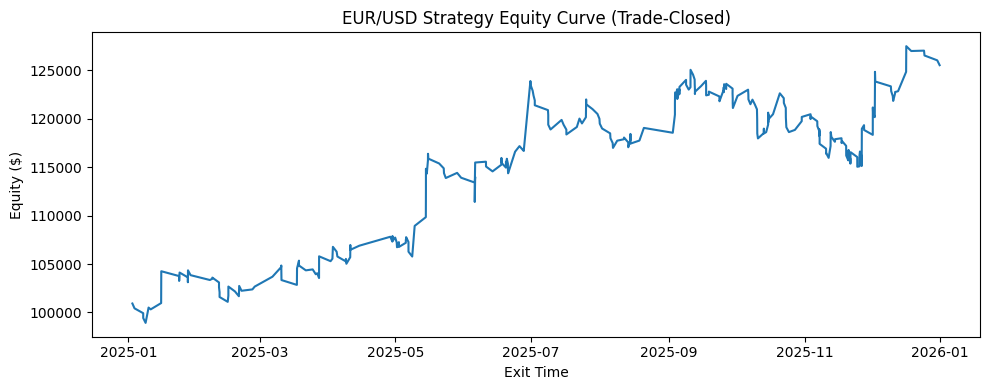

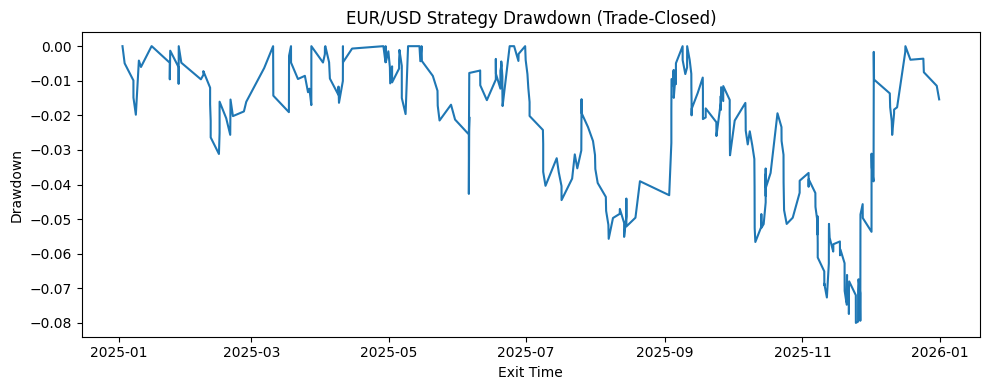

In [ ]:
# =============================================================================
# PIPELINE
# =============================================================================

def run_full_backtest(cfg: BacktestConfig) -> Tuple[pd.DataFrame, pd.DataFrame, Dict, pd.DataFrame]:
    bid = load_jforex_csv(cfg.bid_path)
    ask = load_jforex_csv(cfg.ask_path)

    df = build_price_frame(bid, ask)
    df = add_sessions(df, cfg)
    df = add_asian_range(df)
    df = add_sweeps(df, cfg)

    zones_active = build_htf_fvg(df)
    df, mid15 = prepare_mss_frames(df, cfg)

    signals = build_signals(df, mid15, zones_active, cfg)
    plans = build_trade_plans(df, signals, zones_active, cfg)
    trades = run_strategy(df, plans, cfg)

    metrics, trades_with_eq, _ = compute_metrics(trades, cfg.start_equity)
    summary = make_summary_table(metrics) if metrics else pd.DataFrame()

    return signals, trades_with_eq, metrics, summary


if __name__ == "__main__":
    cfg = BacktestConfig()

    signals, trades_with_eq, metrics, summary = run_full_backtest(cfg)

    print("\n=== SIGNALS ===")
    print(signals.head())

    print("\n=== TRADES ===")
    print(trades_with_eq.head())

    print("\n=== METRICS ===")
    for k, v in metrics.items():
        print(f"{k}: {v}")

    print("\n=== SUMMARY TABLE ===")
    print(summary.T)

    plot_equity_and_drawdown(trades_with_eq)